# Tugas 6 Reduksi Dimensi SVD dan Regresi Logistik

Rafly Faldiansyah Putra

210411100063

Preprocessing hasil crawling data dari kompas.com

## Reduksi Dimensi Transformasi SVD

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
import re
from IPython.display import display, Markdown

# 1. Membaca Dataset
# Membaca file CSV yang berisi dataset
df = pd.read_csv("preprocessing-kompas.csv")

# Mengganti nilai NaN dengan string kosong agar tidak ada data kosong yang menyebabkan error
df['stopword_removal'] = df['stopword_removal'].fillna('')

# 2. Mengonversi Data Teks ke TF-IDF
# Menginisialisasi TfidfVectorizer dengan normalisasi L2
vectorizer = TfidfVectorizer(norm='l2')

# Menghitung nilai TF-IDF untuk setiap dokumen
tfidf_matrix = vectorizer.fit_transform(df['stopword_removal'])

# Mengubah hasil TF-IDF menjadi DataFrame untuk kemudahan akses
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())

# 3. Reduksi Dimensi dengan Truncated SVD
# Menginisialisasi TruncatedSVD untuk mereduksi dimensi menjadi 100 komponen (atau sesuai kebutuhan)
svd = TruncatedSVD(n_components=1000, random_state=42)

# Mengaplikasikan SVD pada matriks TF-IDF untuk menghasilkan matriks dengan dimensi yang lebih rendah
svd_matrix = svd.fit_transform(tfidf_matrix)

# Menyimpan hasil SVD dalam DataFrame untuk digunakan dalam perhitungan kemiripan
svd_df = pd.DataFrame(svd_matrix)

# Menampilkan 10 baris pertama dari DataFrame hasil SVD
svd_df.head(1000)



,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.318048,0.336699,0.001047,0.008270,-0.257332,0.017326,0.159126,-0.324972,-0.082744,0.175946,...,0.025443,0.032022,0.003989,-0.084826,0.001480,0.006058,0.009300,0.029638,0.005525,0.003858
1,0.267889,0.265209,0.001206,-0.001144,-0.145906,0.051709,-0.002118,-0.098570,0.018178,-0.014501,...,-0.071177,-0.047667,-0.032383,0.038653,0.032659,0.012287,-0.018055,0.015435,0.003373,0.001066
2,0.275993,0.289724,0.009255,0.018454,-0.282478,0.025928,0.141696,-0.350281,-0.059327,0.174348,...,0.023016,0.017567,-0.023269,-0.001327,0.025918,-0.024781,0.000734,0.035208,-0.000262,0.001894
3,0.184904,-0.045614,-0.038867,0.105367,-0.001282,-0.128633,0.080001,0.046412,-0.074667,-0.001831,...,0.010405,-0.014090,-0.002174,-0.009361,-0.001838,-0.003785,0.006885,-0.008148,-0.002289,-0.001875
4,0.336624,0.377235,0.005007,-0.022246,-0.212861,0.020914,0.119120,-0.363587,-0.089158,0.186927,...,-0.040972,-0.035931,0.042560,0.074858,0.003522,0.046988,-0.006124,-0.046595,-0.007314,0.000503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.135096,-0.082512,0.057765,-0.012827,0.060773,0.104402,-0.004441,0.079390,0.519378,0.481841,...,-0.004262,-0.002475,-0.001884,-0.054075,-0.008057,-0.005671,-0.015422,-0.000973,0.020449,0.001359
96,0.136410,-0.027847,0.022742,0.016475,-0.004543,0.027487,0.100443,0.050808,0.128822,-0.046311,...,-0.022888,-0.001423,-0.003475,-0.012415,-0.011740,-0.006815,0.001626,0.000196,0.008629,-0.003298
97,0.089245,-0.069275,-0.004827,0.022257,0.011292,-0.018394,0.021997,0.033593,0.044537,-0.002819,...,0.009351,-0.002837,-0.000367,0.014356,0.008336,0.004960,-0.010100,0.001605,0.000423,-0.002849
98,0.127469,-0.039437,0.019895,-0.025436,0.002352,0.022569,-0.000966,0.033656,0.097731,0.022922,...,-0.039153,-0.026095,0.048038,0.021043,-0.016784,0.014634,0.006370,0.006212,0.004308,-0.006296


Confusion Matrix:
[[10  2]
 [ 0  8]]

Hasil Klasifikasi:
              precision    recall  f1-score   support

    Olahraga       1.00      0.83      0.91        12
     Politik       0.80      1.00      0.89         8

    accuracy                           0.90        20
   macro avg       0.90      0.92      0.90        20
weighted avg       0.92      0.90      0.90        20

Akurasi Model: 0.90


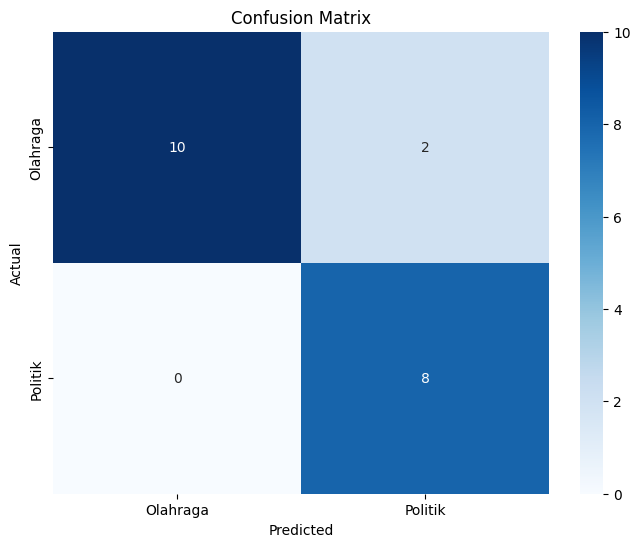

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Menentukan target (y)
y = df['kategori']  # Target adalah kategori berita

# Pisahkan dataset menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(svd_df, y, test_size=0.2, random_state=42)

# Inisialisasi model Regresi Logistik
model = LogisticRegression(max_iter=1000)

# Latih model
model.fit(X_train, y_train)

# Lakukan prediksi pada set pengujian
y_pred = model.predict(X_test)

# Evaluasi model
print("Confusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

print("\nHasil Klasifikasi:")
class_report = classification_report(y_test, y_pred, zero_division=0)
print(class_report)

# Menampilkan akurasi
accuracy = (y_pred == y_test).mean()


print(f"Akurasi Model: {accuracy:.2f}")

# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


## Link App Klasifikasi kategori Berita dengan SVD :
### https://huggingface.co/spaces/Raflyyy/RegresiLogistikSVD